In [1]:
# Run this cell first if geopandas/shapely are not installed
%pip install geopandas shapely matplotlib
%pip install --upgrade fiona geopandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 9.3 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.7/20.7 MB 5.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 12.0 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 439.4 kB/s eta 0:00:0000:0100:04
Note: you may need to restart the kernel to use updated packages.


In [2]:
import geopandas as gpd
import json


# Load the GeoJSON file
gdf = gpd.read_file("vic-lgovt-com-com-clue-floor-use-block-2011-na.json")

# Display basic info
print("CRS:", gdf.crs)  # Check coordinate reference system
print("\nFirst 5 rows:")
print(gdf.head())
print("\nData types:")
print(gdf.dtypes)

CRS: EPSG:4283

First 5 rows:
                                   id  block_id  census_year  clue_small_area  \
0   com_clue_floor_use_block_2011.662       662         2011   East Melbourne   
1  com_clue_floor_use_block_2011.1112      1112         2011        Docklands   
2     com_clue_floor_use_block_2011.6         6         2011  Melbourne (CBD)   
3   com_clue_floor_use_block_2011.927       927         2011        Parkville   
4   com_clue_floor_use_block_2011.926       926         2011        Parkville   

   commercial_accommodation  common_area  community_use  educational_research  \
0                       0.0          0.0            0.0                   0.0   
1                       NaN      10952.0            0.0                   0.0   
2                       0.0      15247.0            0.0                   0.0   
3                       0.0       4163.0            0.0                   0.0   
4                       0.0        236.0            0.0                   0.0 

In [3]:
### Validation Check：Check for overlapping geometries, invalid geometries, and data consistency.

In [4]:
#Check for Valid Geometries

In [5]:
# Validate geometry integrity
invalid_geoms = gdf[~gdf.is_valid]
print(f"Invalid geometries: {len(invalid_geoms)}")

Invalid geometries: 0


In [6]:
#Check for Overlapping Features

In [17]:
from shapely.geometry import Polygon
from itertools import combinations

# Create spatial index for faster queries
sindex = gdf.sindex

# Check overlaps (simplified example for small datasets)
overlaps = []
for idx1, row1 in gdf.iterrows():
    possible_matches = list(sindex.intersection(row1.geometry.bounds))
    for idx2 in possible_matches:
        if idx1 != idx2:
            if row1.geometry.intersects(gdf.iloc[idx2].geometry):
                overlaps.append((idx1, idx2))

print(f"Overlapping feature pairs: {overlaps[:5]}")  # Show first 5 overlaps

Overlapping feature pairs: [(0, 544), (0, 384), (0, 408), (0, 277), (0, 407)]


In [46]:
# Get all overlapping pairs
all_overlaps = [(i, j) for i, j in overlaps if i != j]
print(f"Total overlapping pairs: {len(all_overlaps)}")

Total overlapping pairs: 3828


In [47]:
# Inspect the first overlapping pair
idx1, idx2 = overlaps[0]
feature1 = gdf.iloc[idx1]
feature2 = gdf.iloc[idx2]

print("Feature 1:", feature1["block_id"], feature1["clue_small_area"])
print("Feature 2:", feature2["block_id"], feature2["clue_small_area"])

Feature 1: 662 East Melbourne
Feature 2: 658 East Melbourne


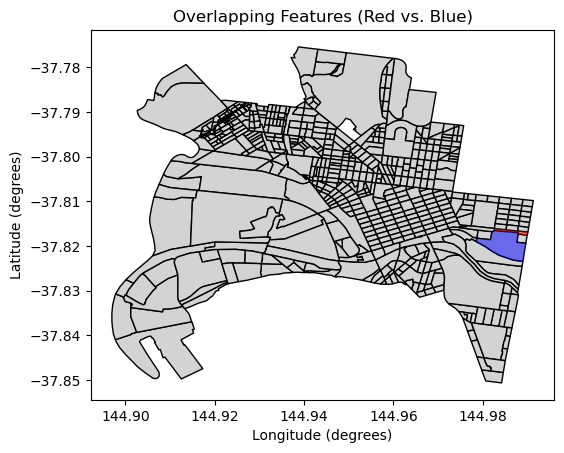

In [51]:
# Convert to GeoDataFrame (preserve geometry)
feature1_gdf = gpd.GeoDataFrame([feature1], geometry='geometry')
feature2_gdf = gpd.GeoDataFrame([feature2], geometry='geometry')

import matplotlib.pyplot as plt

fig, ax = plt.subplots()
gdf.plot(ax=ax, color='lightgray', edgecolor='black')  # Base layer

# Plot overlapping features using GeoPandas
feature1_gdf.plot(ax=ax, color='red', alpha=0.5)
feature2_gdf.plot(ax=ax, color='blue', alpha=0.5)
plt.xlabel("Longitude (degrees)")
plt.ylabel("Latitude (degrees)")

plt.title("Overlapping Features (Red vs. Blue)")
plt.show()

In [48]:
#Attribute Validation

In [22]:
# Check property consistency (e.g., numeric fields)
numeric_fields = ['total_space_in_block', 'residential_apartment']
for field in numeric_fields:
    if gdf[field].dtype != 'float64':
        print(f"Field {field} has incorrect data type: {gdf[field].dtype}")
    else:
        print(f"Field {field} has correct data type: {gdf[field].dtype}")
    

Field total_space_in_block has correct data type: float64
Field residential_apartment has correct data type: float64


In [ ]:
### Format Checks： Verify rules to GeoJSON standards and data structure.

In [ ]:
#Verify CRS (Coordinate Reference System)

In [26]:
# Check if CRS is EPSG:4283
current_crs = gdf.crs  # Get current CRS
print(f"Current CRS: {current_crs}")

#EPSG:4283 (GDA94): Geocentric datum for Australia (also latitude/longitude, but tied to Australian tectonic plate).

Current CRS: EPSG:4283


In [27]:
# Check Required Fields

In [28]:
required_fields = ["block_id", "census_year", "geometry"]
missing = [field for field in required_fields if field not in gdf.columns]
print(f"Missing fields: {missing}")

Missing fields: []


In [29]:
# Check geometry type

In [30]:
allowed_geom_types = ['MultiPolygon', 'Polygon']
invalid_geom_types = gdf[~gdf.geometry.type.isin(allowed_geom_types)]
print(f"Invalid geometry types: {len(invalid_geom_types)}")

Invalid geometry types: 0


In [ ]:
### Registry Check： Manage validation rules centrally 

In [43]:
# Define validation rules
validation_rules = {
    "required_fields": ["block_id", "clue_small_area", "total_space_in_block"],
    "allowed_geometry_types": ["MultiPolygon", "Polygon"],
    "numeric_fields": ["total_space_in_block", "residential_apartment"]}

In [45]:
# Load validation rules
with open("validation_rules.json", "r") as f:
    rules = json.load(f)

# Check required fields
missing_fields = [field for field in rules["required_fields"] if field not in gdf.columns]
print(f"Missing fields: {missing_fields}")

# Check geometry types
invalid_geoms = gdf[~gdf.geometry.type.isin(rules["allowed_geometry_types"])]
print(f"Invalid geometry types: {len(invalid_geoms)}")

Missing fields: []
Invalid geometry types: 0
